# Module 2 — supplement

The two analyses that [the main notebook](module2_biodiversity_neural_networks.ipynb) references but
does not present, moved here to keep it to the length of a 15-minute talk:

1. **Three more models on the raw rating** (section S2). The main notebook's section 6.5 keeps the
   floor and the ordinal cumulative-link model, the two that settle the question. Ridge regression, a
   random forest regressor and method 1's trunk with a linear output answer a narrower question —
   *is the result specific to one model class?* It is: all three score worse than the floor, where the
   ordinal model does not. That is a point about modelling rather than about SLM, which is why it
   sits here and not on a slide.
2. **The method × indicator heat-maps** (section S3), formerly section 7.4 of the main notebook.
   Section 6 there shows the per-indicator predictions have no skill on unseen countries, so these
   maps are the model's *tendencies*, not predictions, and they need a minute of explaining that a
   short talk does not have.

**Section S1 is copied verbatim from the main notebook** (its sections 1, 3 and the trunk of section
5) so that this notebook runs standalone. If you change the features, the folds or the target over
there, copy those cells again. Run time ≈ 4 minutes: the heat-maps need the 15-model multi-task
ensemble retrained here, and the network in S2 is another 15 fits.

## S1. Setup — copied from the main notebook

Sections 1 (imports and plotting conventions), 2 (data and targets), 3 (features, country-grouped
folds, metric helpers) and the model-building half of section 5, unchanged.

In [1]:
import os, sys, time, math, warnings
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"   # reproducible numerics on CPU

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import sklearn
import tensorflow as tf
import keras
from keras import layers

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
SEED = 42
keras.utils.set_random_seed(SEED)

print(f"python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__} | "
      f"tensorflow {tf.__version__} | keras {keras.__version__}")

# plotting conventions
C_BLUE, C_ORANGE, C_AQUA, C_RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
INK, INK_MUTED, GRID, NEUTRAL = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
BLUES = LinearSegmentedColormap.from_list("blues", ["#cde2fb", "#3987e5", "#0d366b"])
BLUE_RED = LinearSegmentedColormap.from_list("blue_red", ["#104281", "#f0efec", "#b03030"])
plt.rc("font", size=11); plt.rc("axes", titlesize=12, labelsize=11, edgecolor=NEUTRAL, labelcolor=INK, axisbelow=True)
plt.rc("grid", color=GRID, linewidth=0.8); plt.rc("xtick", color=INK_MUTED); plt.rc("ytick", color=INK_MUTED)
plt.rc("legend", frameon=False, fontsize=10); plt.rc("figure", facecolor="white", dpi=100)

def tidy(ax, grid_axis="y"):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.grid(False)
    if grid_axis:
        ax.grid(True, axis=grid_axis)
    return ax

python 3.13.14 | pandas 3.0.5 | scikit-learn 1.9.1 | tensorflow 2.21.0 | keras 3.15.1


In [2]:
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "colab" / "datasets" / "wocat"
        if (candidate / "wocat_technologies.csv.gz").is_file():
            return candidate
    raise FileNotFoundError("run this notebook from inside the CAS-AML-WOCAT repository")

DATA = find_data_dir()
wocat = pd.read_csv(DATA / "wocat_technologies.csv.gz")
scores = pd.read_csv(DATA / "impact_scores.csv.gz")

PRETTY = {"vegetation_cover": "Vegetation cover", "biomass_above_ground_C": "Biomass / above-ground C",
          "plant_diversity": "Plant diversity", "animal_diversity": "Animal diversity",
          "beneficial_species": "Beneficial species", "habitat_diversity": "Habitat diversity",
          "invasive_alien_species": "Invasive alien species", "pest_disease_control": "Pest / disease control"}
BIO = list(PRETTY)
TARGET = "biomass_above_ground_C"          # research.md: the main output variable

bio_wide = (scores[scores["block"] == "ecological_biodiversity"]
            .pivot_table(index="technology_id", columns="indicator", values="value", aggfunc="mean").reindex(columns=BIO))
bio_all = wocat.merge(bio_wide, left_on="technology_id", right_index=True, how="inner").reset_index(drop=True)
bio_all["bio_mean"] = bio_all[BIO].mean(axis=1)                  # the secondary target of section 7.2
data = bio_all[bio_all[TARGET].notna()].reset_index(drop=True)   # the technologies that score biomass
MEDIAN = data[TARGET].median()
data["bio_high"] = (data[TARGET] > MEDIAN).astype(int)
y = data["bio_high"].to_numpy()
Y_IND = data[BIO].to_numpy(dtype=np.float32)          # NaN where an indicator was not scored

print(f"{len(wocat):,} technologies, {len(scores):,} individual scores; {len(bio_all)} technologies score at least one "
      f"biodiversity indicator, {len(data)} of them score biomass / above-ground C")
print(f"biomass score: median = {MEDIAN:+.0f}; share above the median ('high') = {y.mean():.2f}; "
      f"share at or above the median = {(data[TARGET] >= MEDIAN).mean():.2f}\n")
scored = bio_all[BIO].notna()
print(pd.DataFrame({"scored (all 895)": scored.sum().values, f"scored (the {len(data)} biomass records)": data[BIO].notna().sum().values,
                    "mean score": bio_all[BIO].mean().round(2).values, "share > 0": ((bio_all[BIO] > 0).sum() / scored.sum()).round(2).values},
                   index=[PRETTY[b] for b in BIO]).to_string())

1,540 technologies, 23,802 individual scores; 895 technologies score at least one biodiversity indicator, 479 of them score biomass / above-ground C
biomass score: median = +2; share above the median ('high') = 0.30; share at or above the median = 0.68

                          scored (all 895)  scored (the 479 biomass records)  mean score  share > 0
Vegetation cover                       350                               200        1.86       0.96
Biomass / above-ground C               479                               479        1.92       0.95
Plant diversity                        475                               291        1.75       0.93
Animal diversity                       249                               157        1.52       0.89
Beneficial species                     281                               175        1.64       0.94
Habitat diversity                      338                               208        1.54       0.88
Invasive alien species                  98    

In [3]:
# the research.md input fields that exist in Dima's table (section 3 lists the ones that do not)
ENVIRONMENT = ["agroclimatic_zone", "slope", "watersupply"]
LAND_USE = ["landuse"]
PRACTICE = ["slm_group", "measures", "degradation", "main_purpose"]
SINGLE, MULTI = ENVIRONMENT, LAND_USE + PRACTICE
BLOCK_OF = {**{c: "environment" for c in ENVIRONMENT}, **{c: "land use" for c in LAND_USE}, **{c: "practice" for c in PRACTICE}}

from sklearn.preprocessing import OneHotEncoder, MultiLabelBinarizer
from sklearn.model_selection import StratifiedGroupKFold, GroupShuffleSplit
from sklearn.metrics import roc_auc_score, f1_score, balanced_accuracy_score

def tokens(series):
    return series.apply(lambda v: v.split("|") if isinstance(v, str) and v else ["MISSING"])

def encode_onehot(df, single=SINGLE, multi=MULTI):
    frames = []
    for col in single:
        enc = OneHotEncoder(sparse_output=False, dtype=np.float32)
        arr = enc.fit_transform(df[[col]].fillna("MISSING").astype(str))
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in enc.categories_[0]], index=df["technology_id"]))
    for col in multi:
        mlb = MultiLabelBinarizer()
        arr = mlb.fit_transform(tokens(df[col]).tolist()).astype(np.float32)
        frames.append(pd.DataFrame(arr, columns=[f"{col}={c}" for c in mlb.classes_], index=df["technology_id"]))
    return pd.concat(frames, axis=1)

X_df = encode_onehot(wocat).loc[data["technology_id"]]
X = X_df.to_numpy(dtype=np.float32)
FIELD_OF = {c: c.split("=")[0] for c in X_df.columns}
groups = data["country_name"].to_numpy()

FOLDS = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED).split(X, y, groups))

def inner_split(train_idx, seed=SEED):
    tr, va = next(GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=seed).split(train_idx, groups=groups[train_idx]))
    return train_idx[tr], train_idx[va]

def scores_from(y_true, p, threshold):
    """AUC ignores the threshold; F1 and balanced accuracy call a record 'high' when p exceeds the training share of 'high'."""
    yhat = (p > threshold).astype(int)
    return {"AUC": roc_auc_score(y_true, p), "macro-F1": f1_score(y_true, yhat, average="macro"),
            "balanced acc.": balanced_accuracy_score(y_true, yhat)}

RESULTS = {}
def record(name, fold_scores, seconds):
    RESULTS[name] = {"folds": fold_scores, "seconds": seconds}
    df = pd.DataFrame(fold_scores)
    print(f"{name:40s} AUC {df['AUC'].mean():.3f} ± {df['AUC'].std():.3f}   macro-F1 {df['macro-F1'].mean():.3f} ± {df['macro-F1'].std():.3f}   ({seconds:4.0f} s)")

def summary_table():
    rows = []
    for name, r in RESULTS.items():
        df = pd.DataFrame(r["folds"])
        rows.append({"approach": name, "AUC": df["AUC"].mean(), "AUC sd": df["AUC"].std(), "macro-F1": df["macro-F1"].mean(),
                     "macro-F1 sd": df["macro-F1"].std(), "balanced acc.": df["balanced acc."].mean(), "seconds": r["seconds"]})
    return pd.DataFrame(rows).set_index("approach")

print(f"{X.shape[0]} technologies x {X.shape[1]} features; {len(set(groups))} countries")
print(pd.DataFrame([{"fold": k, "train": len(tr), "test": len(te), "test countries": len(set(groups[te])),
                     "share high (test)": round(y[te].mean(), 2)} for k, (tr, te) in enumerate(FOLDS)]).set_index("fold").to_string())

479 technologies x 82 features; 87 countries
      train  test  test countries  share high (test)
fold                                                
0       380    99              22               0.30
1       388    91              20               0.29
2       388    91              19               0.30
3       373   106               8               0.33
4       387    92              18               0.28


In [4]:
def dense_trunk(h, hidden=(128, 64), dropout=0.3, l2=1e-4, batchnorm=True, activation="relu", name="trunk"):
    reg = keras.regularizers.l2(l2) if l2 else None
    for i, units in enumerate(hidden):
        h = layers.Dense(units, kernel_initializer="he_normal", use_bias=not batchnorm, kernel_regularizer=reg)(h)
        if batchnorm:
            h = layers.BatchNormalization()(h)
        h = layers.Activation(activation, name=f"{name}_out" if i == len(hidden) - 1 else None)(h)
        if dropout:
            h = layers.Dropout(dropout)(h)
    return h

def build_mlp(hidden=(128, 64), dropout=0.3, l2=1e-4, batchnorm=True, activation="relu", lr=1e-3):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    out = layers.Dense(1, activation="sigmoid", name="bio_high")(dense_trunk(inp, hidden, dropout, l2, batchnorm, activation))
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="binary_crossentropy", metrics=[keras.metrics.AUC(name="auc")])
    return model

def callbacks(patience=15):
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)]

def run_keras_cv(build, Xany, extra_targets=None, name=None, epochs=150, batch_size=32, seed=SEED):
    """Grouped 5-fold CV for a Keras model whose (first) output is the bio_high sigmoid.
    build(train_idx) returns a compiled model. Returns (fold scores, fitted models, histories)."""
    t0, out, models, histories = time.time(), [], [], []
    for k, (tr, te) in enumerate(FOLDS):
        keras.utils.clear_session(); keras.utils.set_random_seed(seed + k)
        tr_in, va_in = inner_split(tr, seed + k)
        target = (lambda idx: y[idx]) if extra_targets is None else (lambda idx: {"bio_high": y[idx], **{n: t[idx] for n, t in extra_targets.items()}})
        model = build(tr_in)
        h = model.fit(Xany[tr_in], target(tr_in), validation_data=(Xany[va_in], target(va_in)),
                      epochs=epochs, batch_size=batch_size, callbacks=callbacks(), verbose=0)
        pred = model.predict(Xany[te], verbose=0)
        p = (pred["bio_high"] if isinstance(pred, dict) else pred).ravel()
        out.append(scores_from(y[te], p, y[tr].mean())); models.append(model); histories.append(h.history)
    if name:
        record(name, out, time.time() - t0)
    return out, models, histories

SEEDS = (SEED, 7, 123)
def run_keras_seeds(build, Xany, extra_targets=None, name=None):
    """run_keras_cv once per seed. On ~380 training rows the seed alone moves a network's AUC by several
    hundredths, so every network result below is a mean over 5 folds x 3 seeds. Models come back seed by seed,
    fold by fold: models[i] was tested on (FOLDS * len(SEEDS))[i]."""
    t0, out, models = time.time(), [], []
    for s in SEEDS:
        fold_scores, fold_models, _ = run_keras_cv(build, Xany, extra_targets, seed=s)
        out += fold_scores; models += fold_models
    if name:
        record(name, out, time.time() - t0)
    return out, models


## S2. The rating as a regression target: does the result depend on the model?

Section 6.5 of the main notebook asks its question with two models: a floor that always answers the
training median, and an ordinal cumulative-link logit. Three more here, on the same folds, the same
82 features and the same 479 records, with the floor repeated so the table reads standalone:

| model | what it is |
|---|---|
| ridge regression | the linear yardstick, the counterpart of logistic regression |
| random forest regressor | the non-linear yardstick |
| feed-forward net (MSE) | method 1's trunk with a linear output instead of a sigmoid, 5 folds × 3 seeds |

The point is agreement, not any single number: if all three land where the ordinal model lands, the
finding is about the data and not about a modelling choice. `reg_scores` and its two helpers are
repeated from section 6.5 so this notebook does not import from the other one.

In [5]:
# reg_scores / record_reg / cv_predictor: repeated from section 6.5 of the main notebook
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

y_raw = data[TARGET].to_numpy(dtype=np.float64)   # the rating itself, not the median split

def reg_scores(te, pred, tr):
    """Ordinal metrics on one test fold. The AUC column scores this same continuous prediction
    against the binary target of the main notebook's section 7.1."""
    resid, base = y_raw[te] - pred, y_raw[te] - y_raw[tr].mean()
    return {"Spearman": pd.Series(y_raw[te]).corr(pd.Series(pred), method="spearman"),   # NaN for a constant prediction
            "MAE": np.abs(resid).mean(),
            "skill": 1 - np.mean(resid ** 2) / np.mean(base ** 2),
            "AUC (binary target)": roc_auc_score(y[te], pred)}

ORDINAL = {}
def record_reg(name, fold_scores, seconds):
    ORDINAL[name] = {"folds": fold_scores, "seconds": seconds}
    df = pd.DataFrame(fold_scores)
    print(f"{name:34s} Spearman {df['Spearman'].mean():+.3f}   MAE {df['MAE'].mean():.3f}   "
          f"skill {df['skill'].mean():+.3f}   AUC {df['AUC (binary target)'].mean():.3f}   ({seconds:4.0f} s)")

def cv_predictor(predict):
    return [reg_scores(te, predict(tr, te), tr) for tr, te in FOLDS]

def build_regressor(hidden=(128, 64), dropout=0.3, l2=1e-4, lr=1e-3):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    out = layers.Dense(1, name="rating")(dense_trunk(inp, hidden, dropout, l2))
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss="mse", metrics=["mae"])
    return model

for label, make in [("0. Always the training median", lambda: DummyRegressor(strategy="median")),
                    ("S1. Ridge regression", lambda: Ridge(alpha=10.0)),
                    ("S2. Random forest regressor",
                     lambda: RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=SEED, n_jobs=-1))]:
    t0 = time.time()
    record_reg(label, cv_predictor(lambda tr, te, make=make: make().fit(X[tr], y_raw[tr]).predict(X[te])), time.time() - t0)

t0, fold_scores = time.time(), []                 # the network, 5 folds x 3 seeds like every other network in module 2
for s in SEEDS:
    for k, (tr, te) in enumerate(FOLDS):
        keras.utils.clear_session(); keras.utils.set_random_seed(s + k)
        tr_in, va_in = inner_split(tr, s + k)
        net = build_regressor()
        net.fit(X[tr_in], y_raw[tr_in], validation_data=(X[va_in], y_raw[va_in]),
                epochs=150, batch_size=32, callbacks=callbacks(), verbose=0)
        fold_scores.append(reg_scores(te, net.predict(X[te], verbose=0).ravel(), tr))
record_reg("S3. Feed-forward net (MSE)", fold_scores, time.time() - t0)

supp_table = pd.DataFrame({k: pd.DataFrame(r["folds"]).mean() for k, r in ORDINAL.items()}).T
supp_table["seconds"] = [r["seconds"] for r in ORDINAL.values()]
print()
print(supp_table.round(3).to_string())
print("\ncompare with the ordinal cumulative-link logit in section 6.5 of the main notebook.")

0. Always the training median      Spearman +nan   MAE 0.684   skill -0.007   AUC 0.500   (   0 s)
S1. Ridge regression               Spearman +0.198   MAE 0.753   skill -0.022   AUC 0.605   (   0 s)


S2. Random forest regressor        Spearman +0.158   MAE 0.745   skill -0.015   AUC 0.604   (   2 s)


S3. Feed-forward net (MSE)         Spearman +0.100   MAE 0.871   skill -0.350   AUC 0.551   ( 117 s)

                               Spearman    MAE  skill  AUC (binary target)  seconds
0. Always the training median       NaN  0.684 -0.007                0.500    0.012
S1. Ridge regression              0.198  0.753 -0.022                0.605    0.021
S2. Random forest regressor       0.158  0.745 -0.015                0.604    2.393
S3. Feed-forward net (MSE)        0.100  0.871 -0.350                0.551  116.713

compare with the ordinal cumulative-link logit in section 6.5 of the main notebook.


**They do not agree with the ordinal model, and that is the result.** All three come out with
*negative* skill — ridge −0.022, the forest −0.015, the network −0.350 — where section 6.5's ordinal
model reaches +0.033, and all three rank worse (Spearman 0.198, 0.158, 0.100 against 0.230; AUC 0.605,
0.604, 0.551 against 0.632). So the ceiling is not purely in the data. Treating a seven-point
questionnaire rating as a *number* to regress loses something that treating it as an *ordered scale*
keeps: the ordinal model never has to decide how far apart +1 and +2 are, it only ever answers "is
this record above this level?", which is the question the fields can actually inform.

**The network is the worst of the three by a distance** (skill −0.350, MAE 0.871 against the floor's
0.684). With a target whose variance is 0.86 and about 380 training rows per fold, minimising MSE
gives it almost nothing to hold on to and it fits noise — the regression version of the failure mode
section 5 of the main notebook shows for the unregularised classifier.

**One caveat on the comparison.** The ordinal model's thresholds use logistic regression at `C = 0.3`
while ridge here uses `alpha = 10`, so part of the gap could be regularisation strength rather than
ordinal structure. The direction is the same for all three regressors and for two very different model
families, which makes the structural reading the more likely one, but a clean test would tune both.

## S3. Which method helps which biodiversity number?

Two heat-maps with the same layout — rows are SLM groups in the what-if order, columns the eight
indicators, colour is the cell minus its column mean (blue = better than the typical method for
that indicator, red = worse). The first is purely descriptive (mean reported score of the biomass
records listing the group; blank where fewer than 8 scores). The second is the model's what-if.
Where both agree we have something to say; where only the raw map is coloured, we are looking at a
handful of records.

This was section 7.4 of the main notebook. Read it against section 6 there: the per-indicator skill
of this network is between −0.2 and 0, so the second map shows what the model *leans* towards, not
what it can predict. The three cells below retrain the 15-model multi-task ensemble and recompute the
what-if table, because this notebook does not share state with the main one.

In [6]:
def masked_mse(y_true, y_pred):
    mask = keras.ops.logical_not(keras.ops.isnan(y_true))
    y_true = keras.ops.where(mask, y_true, keras.ops.zeros_like(y_true))
    m = keras.ops.cast(mask, y_pred.dtype)
    return keras.ops.sum(keras.ops.square(y_true - y_pred) * m) / keras.ops.maximum(keras.ops.sum(m), 1.0)

def masked_mae(y_true, y_pred):
    mask = keras.ops.logical_not(keras.ops.isnan(y_true))
    y_true = keras.ops.where(mask, y_true, keras.ops.zeros_like(y_true))
    m = keras.ops.cast(mask, y_pred.dtype)
    return keras.ops.sum(keras.ops.abs(y_true - y_pred) * m) / keras.ops.maximum(keras.ops.sum(m), 1.0)

def build_multitask(indicator_bias=None, hidden=(128, 64), dropout=0.3, l2=1e-4, lr=1e-3, indicator_weight=0.5):
    inp = keras.Input(shape=(X.shape[1],), name="onehot")
    h = dense_trunk(inp, hidden, dropout, l2)
    out_high = layers.Dense(1, activation="sigmoid", name="bio_high")(h)
    bias_init = keras.initializers.Constant(indicator_bias) if indicator_bias is not None else "zeros"
    out_ind = layers.Dense(len(BIO), name="indicators", bias_initializer=bias_init)(h)
    model = keras.Model(inp, {"bio_high": out_high, "indicators": out_ind})
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr),
                  loss={"bio_high": "binary_crossentropy", "indicators": masked_mse},
                  loss_weights={"bio_high": 1.0, "indicators": indicator_weight},
                  metrics={"bio_high": [keras.metrics.AUC(name="auc")], "indicators": [masked_mae]})
    return model

scores_C, models_C = run_keras_seeds(lambda idx: build_multitask(indicator_bias=np.nanmean(Y_IND[idx], axis=0)),
                                     X, extra_targets={"indicators": Y_IND}, name="2. Multi-task net (8 indicators + high/low)")

2. Multi-task net (8 indicators + high/low) AUC 0.598 ± 0.074   macro-F1 0.464 ± 0.071   (  76 s)


In [7]:
long = data[["bio_high", TARGET]].assign(group=tokens(data["slm_group"])).explode("group")
share_high = long.groupby("group")["bio_high"].mean()
n_group = long.groupby("group").size()
GROUPS_SHOWN = [g for g in n_group.index if n_group[g] >= 15 and g not in ("MISSING", "OTHER")]
SLM_COL = {c.split("=")[1]: j for j, c in enumerate(X_df.columns) if c.startswith("slm_group=")}

def what_if(models, category):
    Xc = X.copy(); Xc[:, list(SLM_COL.values())] = 0.0; Xc[:, SLM_COL[category]] = 1.0
    preds = [m.predict(Xc, verbose=0) for m in models]
    return (np.mean([p["bio_high"].ravel() for p in preds], axis=0).mean(),
            np.mean([p["indicators"] for p in preds], axis=0).mean(axis=0))

adjusted = {}
for g in GROUPS_SHOWN:
    p, ind = what_if(models_C, g)
    adjusted[g] = {"adjusted P(high)": p, **{b: v for b, v in zip(BIO, ind)}}
adjusted = pd.DataFrame(adjusted).T.astype(float)
adjusted["raw share high"] = share_high.reindex(adjusted.index); adjusted["n"] = n_group.reindex(adjusted.index)
adjusted = adjusted.sort_values("adjusted P(high)")


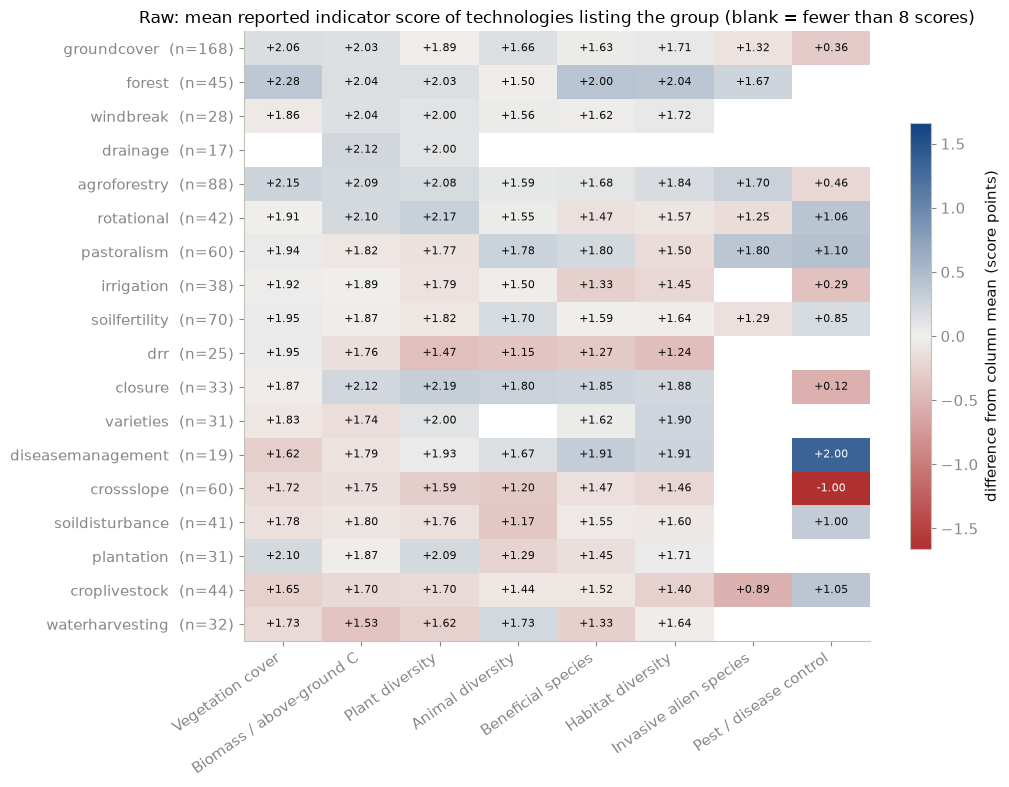

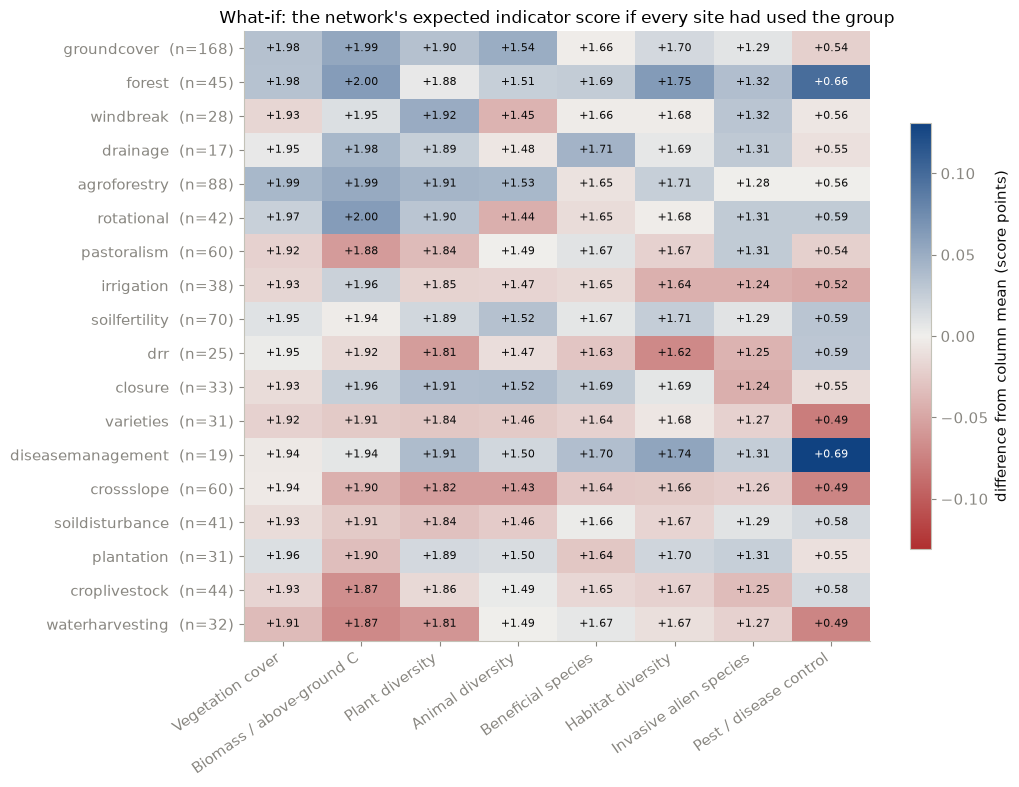

rank agreement raw vs what-if, per indicator (Spearman):
Vegetation cover            0.66
Biomass / above-ground C    0.85
Plant diversity             0.73
Animal diversity            0.50
Beneficial species          0.71
Habitat diversity           0.82
Invasive alien species      0.25
Pest / disease control      0.65


In [8]:
order = adjusted.sort_values("adjusted P(high)", ascending=False).index
long_ind = data[["technology_id"] + BIO].assign(group=tokens(data["slm_group"])).explode("group")
raw_agg = long_ind[long_ind["group"].isin(GROUPS_SHOWN)].groupby("group")[BIO].agg(["mean", "count"])
raw_mean = raw_agg.xs("mean", axis=1, level=1).reindex(columns=BIO).where(raw_agg.xs("count", axis=1, level=1).reindex(columns=BIO) >= 8).loc[order]

def plot_heat(values, title):
    centred = values - values.mean(axis=0); lim = float(np.nanmax(np.abs(centred.values)))
    fig, ax = plt.subplots(figsize=(10.5, 8))
    im = ax.imshow(np.ma.masked_invalid(centred.values), cmap=BLUE_RED.reversed(), vmin=-lim, vmax=lim, aspect="auto")
    ax.set_xticks(range(8), [PRETTY[b] for b in BIO], rotation=35, ha="right")
    ax.set_yticks(range(len(values)), [f"{g.lower()}  (n={int(adjusted.loc[g, 'n'])})" for g in values.index])
    for i in range(values.shape[0]):
        for j in range(values.shape[1]):
            v = values.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8, color="white" if abs(centred.values[i, j]) > 0.6 * lim else INK)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.7, label="difference from column mean (score points)"); tidy(ax, None)
    plt.tight_layout(); plt.show()

plot_heat(raw_mean, "Raw: mean reported indicator score of technologies listing the group (blank = fewer than 8 scores)")
plot_heat(adjusted[BIO].loc[order], "What-if: the network's expected indicator score if every site had used the group")
agreement = pd.Series({PRETTY[b]: raw_mean[b].corr(adjusted[b].loc[order], method="spearman") for b in BIO}).round(2)
print("rank agreement raw vs what-if, per indicator (Spearman):"); print(agreement.to_string())